# Ablation — Full Model Quantization (all tensors)

Sweeps `quant_bits` ∈ {8, 6, 4} with `QUANTIZE_ALL=1` (1 seed).

| config | meaning |
|---|---|
| `bits = 8` | all tensors quantized to int8 (±127) |
| `bits = 6` | all tensors quantized to int6 (±31) stored in int8 container |
| `bits = 4` | all tensors quantized to int4 (±7) stored in int8 container |

In the baseline, small tensors (≤65,536 elements) and control tensors (`attn_scale`, `mlp_scale`, `resid_mix`, `q_gain`, `skip_weights`) bypass quantization and are kept in fp16/fp32. Here we remove that bypass and quantize **everything** — including these sensitive vectors — to measure their contribution to file size and BPB.

## Goal

This ablation answers two questions:
1. **How much additional file size do we save** by quantizing the small/control tensors, compared to only quantizing 2D matrices?
2. **How much BPB do we lose** from quantizing these sensitive parameters?

We compare these results against the 2D-matrices-only ablation to determine whether the extra savings justify the BPB cost.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import wandb
import importlib, utils
importlib.reload(utils)
from utils import apply_style, get_deep_palette

apply_style(force=True)
PALETTE = get_deep_palette()

ENTITY  = "the-golfers"
PROJECT = "ml_ai_project"

api = wandb.Api()

# Human-readable labels and display order
BITS_ORDER  = [8, 6, 4]
BITS_LABELS = {
    8:  "int8",
    6:  "int6",
    4:  "int4",
}
BITS_COLORS = {b: PALETTE[i] for i, b in enumerate(BITS_ORDER)}

## Original Baseline (3 seeds, reference)

In [3]:
BASELINE_PREFIX = "golf_baseline_antonio_new"

baseline_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{BASELINE_PREFIX}"}},
))

baseline_rows = []
for run in baseline_runs:
    s = run.summary._json_dict
    baseline_rows.append({
        "seed":             run.config.get("seed"),
        "final_val_bpb":    s.get("final_val_bpb"),
        "final_val_loss":   s.get("final_val_loss"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_base = pd.DataFrame(baseline_rows).sort_values("seed").reset_index(drop=True)
BASE_BPB_MEAN  = df_base["final_val_bpb"].mean()
BASE_BPB_STD   = df_base["final_val_bpb"].std()
BASE_SIZE_MEAN = df_base["quant_file_bytes"].mean()

print("=" * 55)
print("ORIGINAL BASELINE  (3 seeds)")
print("=" * 55)
print(df_base.to_string(index=False))
print(f"\nfinal_val_bpb : {BASE_BPB_MEAN:.4f} ± {BASE_BPB_STD:.4f}")
print(f"file size     : {BASE_SIZE_MEAN / 1e6:.2f} MB")
print("=" * 55)

ORIGINAL BASELINE  (3 seeds)
 seed  final_val_bpb  final_val_loss  quant_file_bytes
   42       1.311465        2.214354          15782427
  123       1.309002        2.210195          15785894
 1337       1.309833        2.211598          15776355

final_val_bpb : 1.3101 ± 0.0013
file size     : 15.78 MB


## Ablation — All Tensors Quantized

In [14]:
ABL_PREFIX = "ablation_full_quantization"

abl_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL_PREFIX}"}},
))

rows = []
for run in abl_runs:
    s   = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", 8)

    # fp32 BPB: last val_bpb logged during training (before quantization)
    hist = run.history(keys=["_step", "val_bpb"], pandas=True)
    fp32_bpb = hist["val_bpb"].dropna().iloc[-1] if not hist.empty else None

    rows.append({
        "run_name":          run.name,
        "matrix_quant_bits": bits,
        "label":             BITS_LABELS.get(bits, str(bits)),
        "seed":              cfg.get("seed"),
        "fp32_val_bpb":      fp32_bpb,
        "final_val_bpb":     s.get("final_val_bpb"),
        "final_val_loss":    s.get("final_val_loss"),
        "quant_file_bytes":  s.get("quant_file_bytes"),
    })

df = (
    pd.DataFrame(rows)
    .assign(bits_order=lambda d: d["matrix_quant_bits"].map({v: i for i, v in enumerate(BITS_ORDER)}))
    .sort_values("bits_order")
    .reset_index(drop=True)
    .drop(columns="bits_order")
)

# Compute delta (quantization damage)
df["delta_bpb"] = df["final_val_bpb"] - df["fp32_val_bpb"]

df

,run_name,matrix_quant_bits,label,seed,fp32_val_bpb,final_val_bpb,final_val_loss,quant_file_bytes,delta_bpb
0,ablation_full_quantization_seed1337,8,int8,1337,1.305718,1.309143,2.210433,15724762,0.003425
1,ablation_full_quantization_seed42,8,int8,42,1.307086,1.311167,2.213851,15733963,0.004081
2,ablation_full_quantization_seed123,8,int8,123,1.305119,1.308684,2.209657,15734716,0.003565
3,ablation_full_quantization_seed1337,6,int6,1337,1.305871,1.363597,2.302376,11841639,0.057725
4,ablation_full_quantization_seed42,6,int6,42,1.307181,1.374500,2.320786,11846206,0.067319
5,ablation_full_quantization_seed123,6,int6,123,1.305578,1.363784,2.302692,11844371,0.058206
6,ablation_full_quantization_seed1337,4,int4,1337,1.305874,2.280447,3.850440,7787322,0.974574
7,ablation_full_quantization_seed42,4,int4,42,1.307059,2.297859,3.879839,7789917,0.990800
8,ablation_full_quantization_seed123,4,int4,123,1.305376,2.345857,3.960881,7797157,1.040481


### Compressed file size vs bitwidth

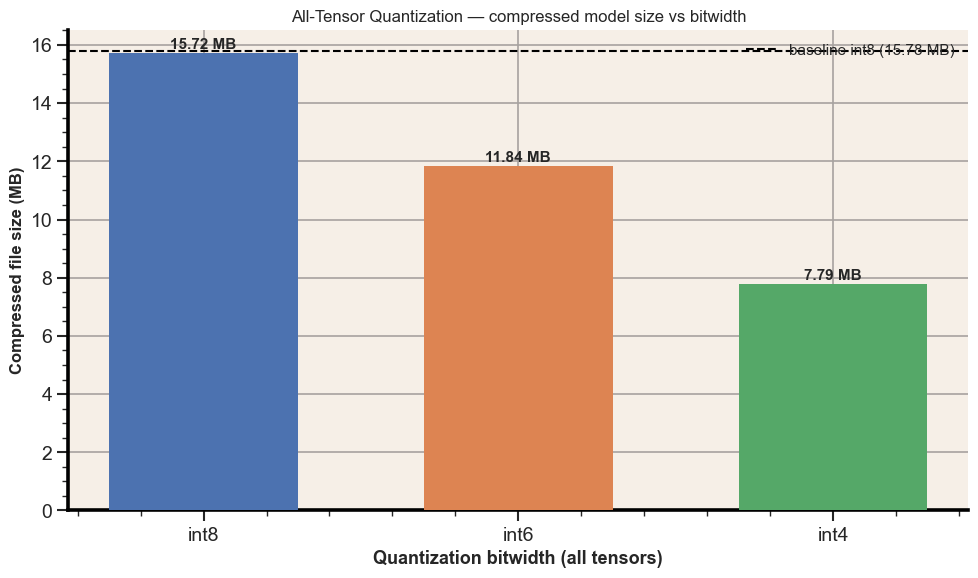

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

bits_vals = [b for b in BITS_ORDER if b in df["matrix_quant_bits"].values]
size_mb   = [df.loc[df["matrix_quant_bits"] == b, "quant_file_bytes"].values[0] / 1e6
             for b in bits_vals]
colors    = [BITS_COLORS[b] for b in bits_vals]

ax.bar(range(len(bits_vals)), size_mb, color=colors, width=0.6, zorder=3)

for i, (b, mb) in enumerate(zip(bits_vals, size_mb)):
    ax.text(i, mb + 0.05, f"{mb:.2f} MB", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

# baseline reference line
ax.axhline(BASE_SIZE_MEAN / 1e6, color="black", linewidth=1.5, linestyle="--",
           label=f"baseline int8 ({BASE_SIZE_MEAN / 1e6:.2f} MB)")

ax.set_xticks(range(len(bits_vals)))
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth (all tensors)", fontsize=13, fontweight="bold")
ax.set_ylabel("Compressed file size (MB)", fontsize=12)
ax.set_title("All-Tensor Quantization — compressed model size vs bitwidth", fontsize=12)
ax.legend(fontsize=11, loc="upper right")
plt.tight_layout(pad=1.5)
plt.show()

### Round-trip BPB and quantization damage vs bitwidth

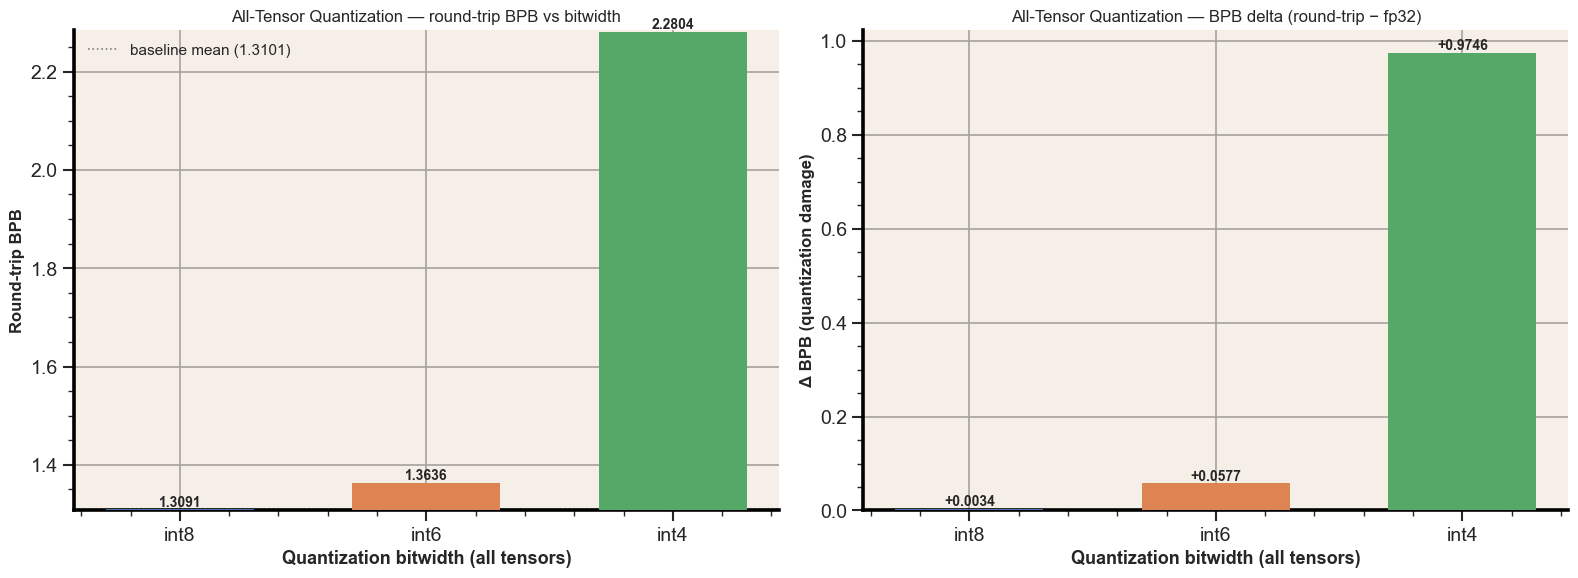

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bits_vals = [b for b in BITS_ORDER if b in df["matrix_quant_bits"].values]
roundtrip = [df.loc[df["matrix_quant_bits"] == b, "final_val_bpb"].values[0]
             for b in bits_vals]
deltas    = [df.loc[df["matrix_quant_bits"] == b, "delta_bpb"].values[0]
             for b in bits_vals]
colors    = [BITS_COLORS[b] for b in bits_vals]

# --- Round-trip BPB ---
ax = axes[0]
ax.bar(range(len(bits_vals)), roundtrip, color=colors, width=0.6, zorder=3)

for i, (b, bpb) in enumerate(zip(bits_vals, roundtrip)):
    ax.text(i, bpb + 0.0005, f"{bpb:.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline mean ({BASE_BPB_MEAN:.4f})")
ax.set_xticks(range(len(bits_vals)))
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth (all tensors)", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("All-Tensor Quantization — round-trip BPB vs bitwidth", fontsize=12)
ax.legend(fontsize=11)

ymin = min(roundtrip) - 0.002
ymax = max(roundtrip) + 0.004
ax.set_ylim(ymin, ymax)

# --- Delta (quantization damage) ---
ax = axes[1]
ax.bar(range(len(bits_vals)), deltas, color=colors, width=0.6, zorder=3)

for i, (b, d) in enumerate(zip(bits_vals, deltas)):
    ax.text(i, d + 0.0003, f"{d:+.4f}", ha="center", va="bottom",
            fontsize=10, fontweight="bold")

ax.axhline(0.0, color="grey", linewidth=1.2, linestyle=":")
ax.set_xticks(range(len(bits_vals)))
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth (all tensors)", fontsize=13, fontweight="bold")
ax.set_ylabel("Δ BPB (quantization damage)", fontsize=12)
ax.set_title("All-Tensor Quantization — BPB delta (round-trip − fp32)", fontsize=12)

plt.tight_layout(pad=1.5)
plt.show()

### Comparison: all-tensor vs 2D-only quantization

This section compares the results of quantizing all tensors vs only quantizing 2D matrices (from the previous ablation), to measure the marginal impact of also quantizing the small/control tensors.

In [27]:
# Fetch 2D-only ablation results for comparison
ABL_2D_PREFIX = "golf_2d_matrices_quantization_ablation"

abl_2d_runs = list(api.runs(
    f"{ENTITY}/{PROJECT}",
    filters={"display_name": {"$regex": f"^{ABL_2D_PREFIX}"}},
))

rows_2d = []
for run in abl_2d_runs:
    s   = run.summary._json_dict
    cfg = run.config
    bits = cfg.get("matrix_quant_bits", 8)
    rows_2d.append({
        "matrix_quant_bits":       bits,
        "final_val_bpb":    s.get("final_val_bpb"),
        "quant_file_bytes": s.get("quant_file_bytes"),
    })

df_2d = pd.DataFrame(rows_2d)

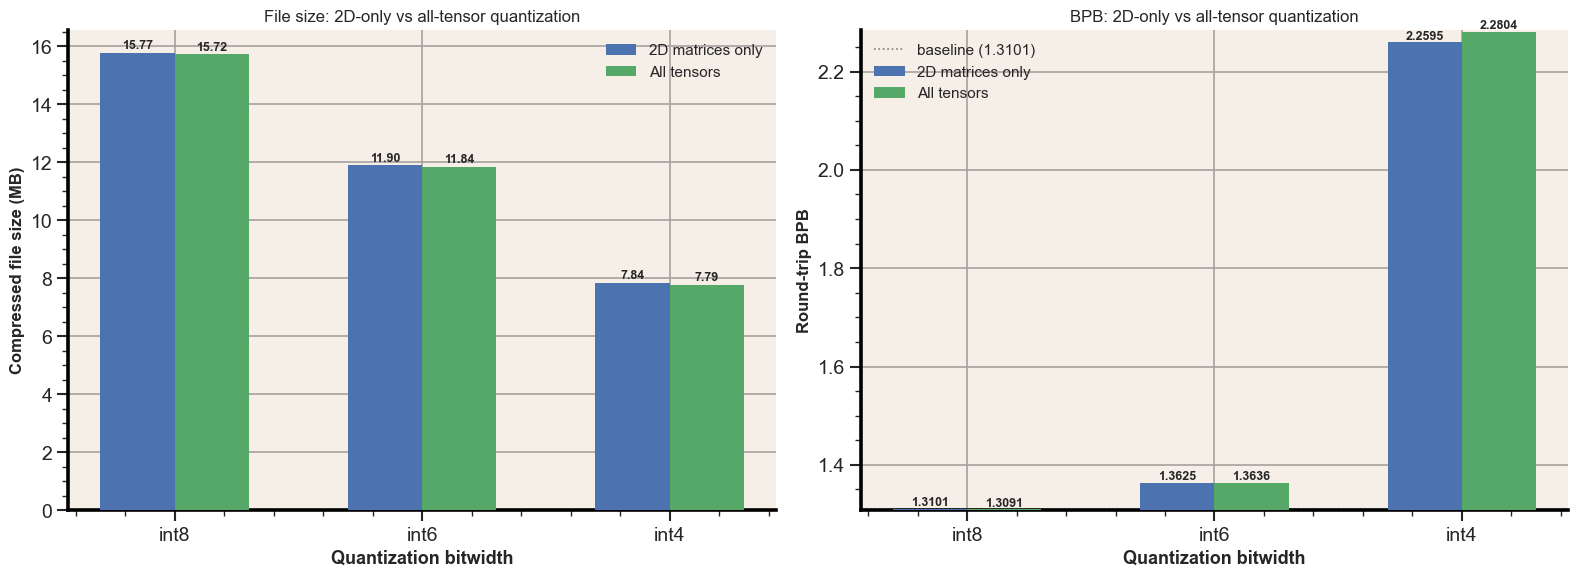

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bits_vals = [b for b in BITS_ORDER if b in df["matrix_quant_bits"].values
             and b in df_2d["matrix_quant_bits"].values]

x = np.arange(len(bits_vals))
width = 0.3

# --- File size comparison ---
ax = axes[0]
size_2d  = [df_2d.loc[df_2d["matrix_quant_bits"] == b, "quant_file_bytes"].values[0] / 1e6
            for b in bits_vals]
size_all = [df.loc[df["matrix_quant_bits"] == b, "quant_file_bytes"].values[0] / 1e6
            for b in bits_vals]

bars1 = ax.bar(x - width/2, size_2d,  width, label="2D matrices only", color=PALETTE[0], zorder=3)
bars2 = ax.bar(x + width/2, size_all, width, label="All tensors",      color=PALETTE[2], zorder=3)

for bar_group, sizes in [(bars1, size_2d), (bars2, size_all)]:
    for bar, mb in zip(bar_group, sizes):
        ax.text(bar.get_x() + bar.get_width()/2, mb + 0.03, f"{mb:.2f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Compressed file size (MB)", fontsize=12)
ax.set_title("File size: 2D-only vs all-tensor quantization", fontsize=12)
ax.legend(fontsize=11)

# --- BPB comparison ---
ax = axes[1]
bpb_2d  = [df_2d.loc[df_2d["matrix_quant_bits"] == b, "final_val_bpb"].values[0]
            for b in bits_vals]
bpb_all = [df.loc[df["matrix_quant_bits"] == b, "final_val_bpb"].values[0]
            for b in bits_vals]

bars1 = ax.bar(x - width/2, bpb_2d,  width, label="2D matrices only", color=PALETTE[0], zorder=3)
bars2 = ax.bar(x + width/2, bpb_all, width, label="All tensors",      color=PALETTE[2], zorder=3)

for bar_group, bpbs in [(bars1, bpb_2d), (bars2, bpb_all)]:
    for bar, bpb in zip(bar_group, bpbs):
        ax.text(bar.get_x() + bar.get_width()/2, bpb + 0.0003, f"{bpb:.4f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(BASE_BPB_MEAN, color="grey", linewidth=1.2, linestyle=":",
           label=f"baseline ({BASE_BPB_MEAN:.4f})")
ax.set_xticks(x)
ax.set_xticklabels([BITS_LABELS[b] for b in bits_vals])
ax.set_xlabel("Quantization bitwidth", fontsize=13, fontweight="bold")
ax.set_ylabel("Round-trip BPB", fontsize=12)
ax.set_title("BPB: 2D-only vs all-tensor quantization", fontsize=12)
ax.legend(fontsize=11)

ymin = min(bpb_2d + bpb_all) - 0.002
ymax = max(bpb_2d + bpb_all) + 0.004
ax.set_ylim(ymin, ymax)

plt.tight_layout(pad=1.5)
plt.show()

### Summary table

In [30]:
rows_summary = [{
    "config":         "Original baseline (3 seeds)",
    "scope":          "2D only",
    "val_bpb":        BASE_BPB_MEAN,
    "val_bpb_std":    BASE_BPB_STD,
    "Δ vs baseline":  0.0,
    "file_size_MB":   BASE_SIZE_MEAN / 1e6,
}]

for b in BITS_ORDER:
    # 2D-only
    sub_2d = df_2d[df_2d["matrix_quant_bits"] == b]
    if not sub_2d.empty:
        row = sub_2d.iloc[0]
        rows_summary.append({
            "config":         f"{BITS_LABELS[b]} — 2D only",
            "scope":          "2D only",
            "val_bpb":        row["final_val_bpb"],
            "val_bpb_std":    float("nan"),
            "Δ vs baseline":  row["final_val_bpb"] - BASE_BPB_MEAN,
            "file_size_MB":   row["quant_file_bytes"] / 1e6,
        })

    # All tensors
    sub_all = df[df["matrix_quant_bits"] == b]
    if not sub_all.empty:
        row = sub_all.iloc[0]
        rows_summary.append({
            "config":         f"{BITS_LABELS[b]} — all tensors",
            "scope":          "all",
            "val_bpb":        row["final_val_bpb"],
            "val_bpb_std":    float("nan"),
            "Δ vs baseline":  row["final_val_bpb"] - BASE_BPB_MEAN,
            "file_size_MB":   row["quant_file_bytes"] / 1e6,
        })

df_summary = pd.DataFrame(rows_summary)
df_summary["val_bpb"]      = df_summary["val_bpb"].map(lambda x: f"{x:.4f}")
df_summary["val_bpb_std"]  = df_summary["val_bpb_std"].map(lambda x: f"±{x:.4f}" if not np.isnan(x) else "—")
df_summary["Δ vs baseline"] = df_summary["Δ vs baseline"].map(lambda x: f"{x:+.4f}")
df_summary["file_size_MB"] = df_summary["file_size_MB"].map(lambda x: f"{x:.2f}")

print(df_summary.drop(columns="scope").to_string(index=False))

# Conclusion
print("\n" + "=" * 60)
if not df.empty and not df_2d.empty:
    for b in BITS_ORDER:
        sub_2d  = df_2d[df_2d["matrix_quant_bits"] == b]
        sub_all = df[df["matrix_quant_bits"] == b]
        if not sub_2d.empty and not sub_all.empty:
            size_diff = (sub_2d.iloc[0]["quant_file_bytes"] - sub_all.iloc[0]["quant_file_bytes"]) / 1e3
            bpb_diff  = sub_all.iloc[0]["final_val_bpb"] - sub_2d.iloc[0]["final_val_bpb"]
            print(f"{BITS_LABELS[b]}: quantizing small tensors saves {size_diff:.1f} KB "
                  f"but costs {bpb_diff:+.4f} BPB")

                     config val_bpb val_bpb_std Δ vs baseline file_size_MB
Original baseline (3 seeds)  1.3101     ±0.0013       +0.0000        15.78
             int8 — 2D only  1.3101           —       +0.0000        15.77
         int8 — all tensors  1.3091           —       -0.0010        15.72
             int6 — 2D only  1.3625           —       +0.0524        11.90
         int6 — all tensors  1.3636           —       +0.0535        11.84
             int4 — 2D only  2.2595           —       +0.9494         7.84
         int4 — all tensors  2.2804           —       +0.9703         7.79

int8: quantizing small tensors saves 44.1 KB but costs -0.0010 BPB
int6: quantizing small tensors saves 54.5 KB but costs +0.0011 BPB
int4: quantizing small tensors saves 54.7 KB but costs +0.0210 BPB
